# Tutorial 7: Integrating Alzheimer's mouse brain data
This tutorial demonstrates SpaTemporal's capabilities in investigating the progression of Alzheimer's disease. The raw data can be downloaded from:https://singlecell.broadinstitute.org/single_cell/study/SCP1375/integrative-in-situ-mapping-of-single-cell-transcriptional-states-and-tissue-histopathology-in-an-alzheimer-disease-model#study-download., or from our hosted repository on Zenodo at https://zenodo.org/records/19591185.

## Preparation

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from graph_3D import *
from train import *
from utils import *

os.environ['R_HOME'] = "/root/miniconda3/envs/njy1/lib/R"
os.environ['R_USER'] = "/root/miniconda3/envs/PyG/lib/python3.8/site-packages/rpy2"

In [2]:
fix_seed(42)

## Load Data

In [3]:
data_root = Path('../Data/Alzheimer/')

proj_list = [
    '8months-control-replicate_1', '8months-disease-replicate_2', '13months-control-replicate_1', '13months-disease-replicate_1', 
]

## Construction of the Spatiotemporal Neighbor Graph

In [4]:
adata, graph_dict = spatiotemporal_graph_(proj_list, k_cutoff=12, scale_factor=1, mode="KNN", rad_cutoff=0.15, data_root=data_root, dataset='Alzheimer')

Reading data.


 25%|██▌       | 1/4 [00:00<00:00,  8.07it/s]

adata 8months-control-replicate_1 shape: (8506, 2765)
adata 8months-disease-replicate_2 shape: (8202, 2765)


 50%|█████     | 2/4 [00:01<00:01,  1.49it/s]

adata 13months-control-replicate_1 shape: (8034, 2765)


 75%|███████▌  | 3/4 [00:02<00:01,  1.07s/it]

adata 13months-disease-replicate_1 shape: (10372, 2765)


100%|██████████| 4/4 [00:04<00:00,  1.23s/it]


Finished reading data.


## Data Preprocessing

In [8]:
adata.layers['count'] = adata.X
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

## Running SpaTemporal

In [10]:
my_net = Train(adata, graph_dict, rec_weight=1, self_weight=50, tri_weight=1, pre_epochs=500, epochs=500, mask_rate=0.2, lr=5e-4, decay=1e-4, mask_mode='token', device='cuda:0')
print_model_parameters(my_net)
my_net.train_final_model(num_cluster=12, method='kmeans', margin=1)    ###method=['mclust', 'kmeans']
 
get_gpu_memory()


## 📋 Model Parameters Information ##
* model.enc_mask_token           | Shape: [1, 200]
* model.encoder.encoder_L1.0.weight | Shape: [64, 200]
* model.encoder.encoder_L1.0.bias | Shape: [64]
* model.encoder.encoder_L1.1.weight | Shape: [64]
* model.encoder.encoder_L1.1.bias | Shape: [64]
* model.encoder.encoder_L2.0.weight | Shape: [16, 64]
* model.encoder.encoder_L2.0.bias | Shape: [16]
* model.encoder.encoder_L2.1.weight | Shape: [16]
* model.encoder.encoder_L2.1.bias | Shape: [16]
* model.gc1.bn.weight            | Shape: [64]
* model.gc1.bn.bias              | Shape: [64]
* model.gc1.conv.bias            | Shape: [64]
* model.gc1.conv.lin.weight      | Shape: [64, 16]
* model.gc2.bn.weight            | Shape: [16]
* model.gc2.bn.bias              | Shape: [16]
* model.gc2.conv.bias            | Shape: [16]
* model.gc2.conv.lin.weight      | Shape: [16, 64]
* model.decoder.bn.weight        | Shape: [200]
* model.decoder.bn.bias          | Shape: [200]
* model.decoder.conv.bias     

100%|██████████| 500/500 [03:47<00:00,  2.20it/s, Rec_L=1.9862, Self_L=0.1416, Total_L=9.3951, Tri_L=0.3282] 


GPU 0: 3277 MiB / 24564 MiB


In [11]:
latent_z, x_recon = my_net.embedding()
adata.obsm['latent'] = latent_z
adata.obsm['x_recon'] = x_recon

## Clustering

In [12]:
mclust_R(adata, num_cluster=12, used_obsm='latent')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 35114 × 2000
    obs: 'X', 'Y', 'X-scaled', 'Y-scaled', 'label', 'top_level_cell_type', 'sub_level_cell_type', 'timepoint', 'batch', 'timepoint_numeric', 'mclust'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'spatial', 'spatial_scaled', 'loc_scaled', 'X_pca', 'latent', 'x_recon'
    layers: 'count'

## Spatial Visualization

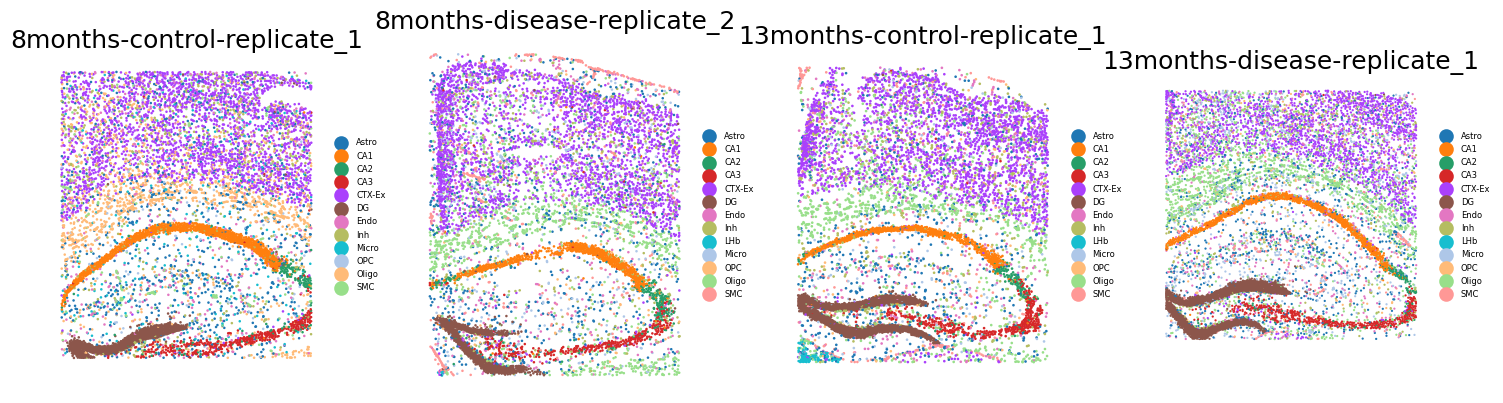

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
k = 1
spot_size = 200
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['timepoint'] == proj_list[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['top_level_cell_type'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    ax.invert_yaxis()
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

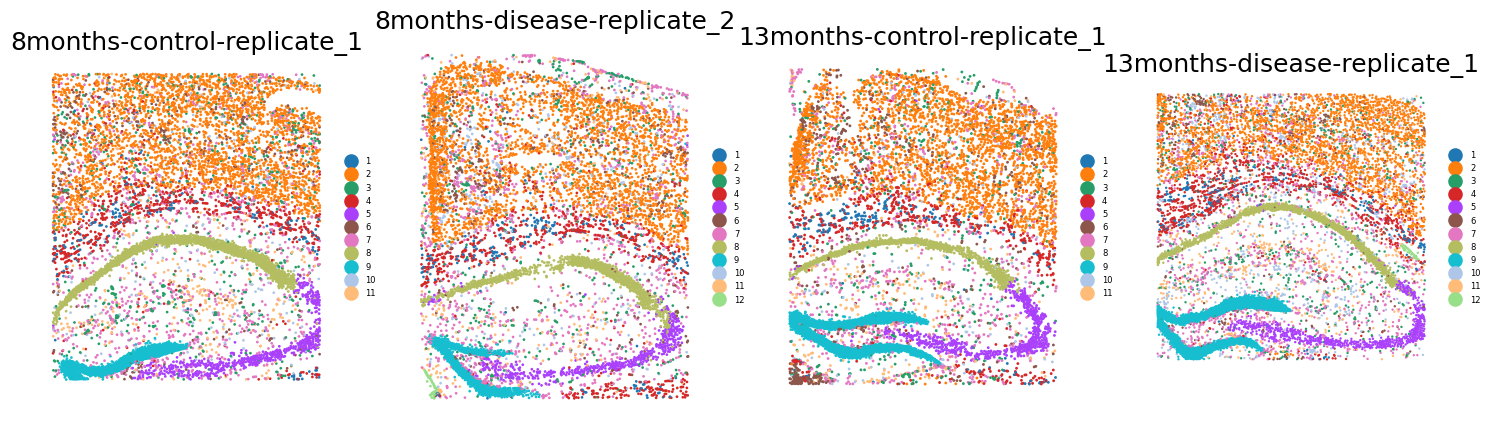

In [22]:
plt.figure(figsize=(15, 10))
k = 1
spot_size = 200
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['timepoint'] == proj_list[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    ax.invert_yaxis()
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()